Dataset Sample:
   Glucose  BloodPressure  SkinThickness  Insulin        BMI  \
0      193             72             25      169  23.722020   
1      200            107             40       48  39.019181   
2      165             59             26      165  38.047034   
3      152            101             10      300  44.676570   
4      171             85             27      108  29.709714   

   DiabetesPedigreeFunction  Age  Outcome  
0                  0.287041   42        0  
1                  1.276820   26        0  
2                  1.303484   37        0  
3                  0.370960   25        0  
4                  0.520054   39        0  


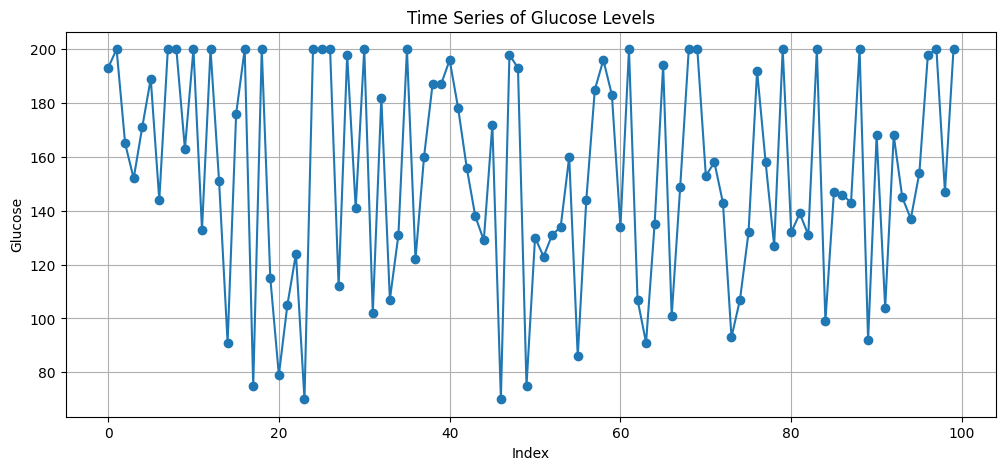

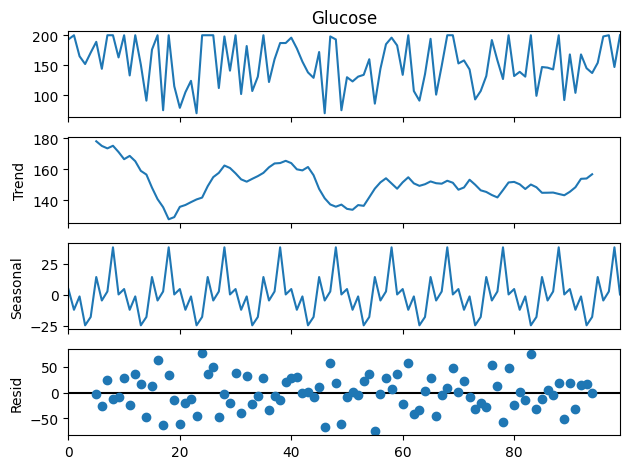

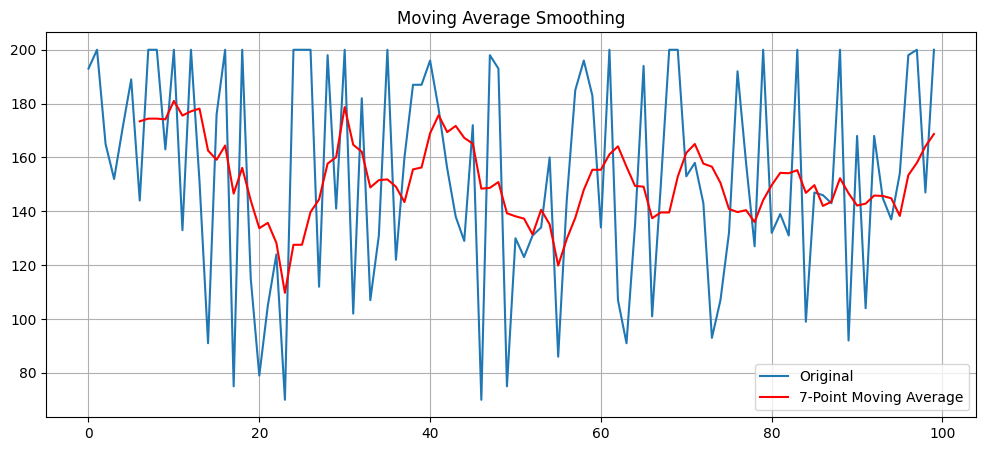

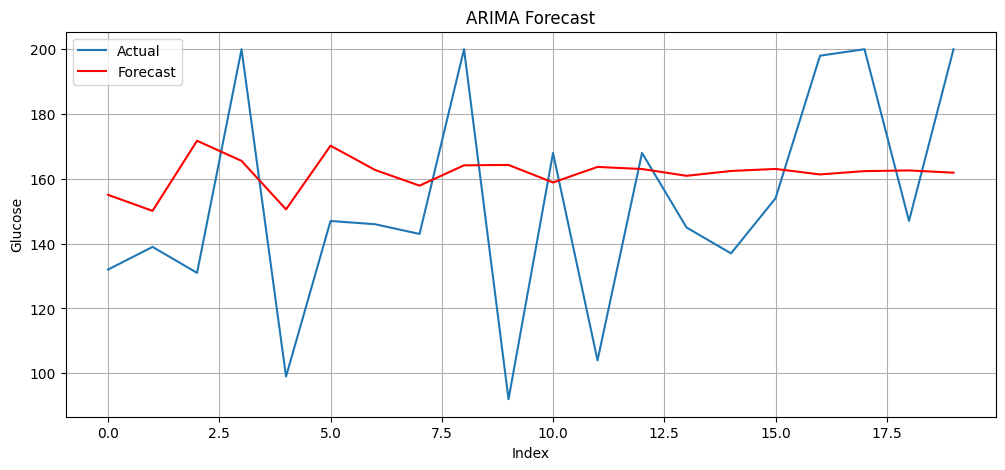

In [39]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

# Load Dataset
diabetes_data = pd.read_csv('/content/uci_diabetes.csv')

# Display Dataset
print("Dataset Sample:")
print(diabetes_data.head())

# Plot Time Series
plt.figure(figsize=(12,5))
plt.plot(diabetes_data["Glucose"], marker='o')
plt.title("Time Series of Glucose Levels")
plt.xlabel("Index")
plt.ylabel("Glucose")
plt.grid(True)
plt.show()

# Seasonal Decomposition
decomposition = seasonal_decompose(
    diabetes_data["Glucose"],
    model="additive",
    period=10
)

decomposition.plot()
plt.show()

# Moving Average
diabetes_data["Glucose_MA"] = diabetes_data["Glucose"].rolling(window=7).mean()

plt.figure(figsize=(12,5))
plt.plot(diabetes_data["Glucose"], label="Original")
plt.plot(diabetes_data["Glucose_MA"], color="red", label="7-Point Moving Average")
plt.title("Moving Average Smoothing")
plt.legend()
plt.grid(True)
plt.show()

# Train/Test Split
train_size = int(len(diabetes_data) * 0.8)

train = diabetes_data["Glucose"][:train_size]
test = diabetes_data["Glucose"][train_size:]

# ARIMA Model
model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

# Forecast
forecast = model_fit.forecast(steps=len(test))

# Plot Forecast
plt.figure(figsize=(12,5))
plt.plot(test.values, label="Actual")
plt.plot(forecast.values, color="red", label="Forecast")
plt.title("ARIMA Forecast")
plt.xlabel("Index")
plt.ylabel("Glucose")
plt.legend()
plt.grid(True)
plt.show()